<table>
  <tr>
    <td><div align="left"><font size="30">Block-diagram simulation</font></div></td>
    <td><img src="https://raw.githubusercontent.com/petercorke/bdsim/master/figs/BDSimLogo_NoBackgnd%402x.png" width="300"></td>
  </tr>
</table>

<p></p>
<table align="center" style="border: none; border-collapse: collapse;">
  <tr>
    <td style="border: none; font-size: 1.5em; padding: 2px 8px;">🧠</td>
    <td style="border: none; font-size: 1.5em; padding: 2px 8px;">Block diagram thinking</td>
  </tr>
  <tr>
    <td style="border: none; font-size: 1.5em; padding: 2px 8px;">🐍</td>
    <td style="border: none; font-size: 1.5em; padding: 2px 8px;">Python coding</td>
  </tr>
</table>

(c) Peter Corke 2026

In [22]:
import importlib
import setup_tutorial
importlib.reload(setup_tutorial)
await setup_tutorial.setup_tutorial(required_toolboxes=['bdsim', 'roboticstoolbox'], required_packages=['matplotlib', 'numpy', 'scipy'])

import bdsim
import matplotlib.pyplot as plt
import numpy as np
import scipy

print("\nRunning bdsim version", bdsim.__version__)

Setting up tutorial environment — wait for the ✅
setup_tutorial: environment=local Python
setup_tutorial: required_toolboxes=['bdsim', 'roboticstoolbox']
setup_tutorial: required_packages=['matplotlib', 'numpy', 'scipy']
setup_tutorial: toolbox 'bdsim' source=already installed in environment
setup_tutorial: toolbox 'roboticstoolbox' source=already installed in environment
✅ Setup complete — toolboxes: bdsim, roboticstoolbox; packages: matplotlib, numpy, scipy

Running bdsim version 1.3.0


# A first-order system




Here's a hand drawn sketch of a simple first-order system with proportional feedback

![Block diagram sketch](https://raw.github.com/petercorke/bdsim/main/docs/figs/bd1-sketch.png)

We model it using `bdsim` by writing Python code to represent the model.  Python means you can use your
favourite IDE, debugger, and version control.

In [ ]:
sim = bdsim.BDSim(animation=True)  # create simulator
bd = sim.blockdiagram()  # create an empty block diagram

# define the blocks
demand = bd.STEP(T=1, name="demand")
sum = bd.SUM("+-")
gain = bd.GAIN(10)
plant = bd.LTI_SISO(0.5, [2, 1], name="plant")
scope = bd.SCOPE(styles=["k", "r--"], loc="lower right")

# connect the blocks
bd.connect(demand, sum[0], scope[1])
bd.connect(plant, sum[1])
bd.connect(sum, gain)
bd.connect(gain, plant)
bd.connect(plant, scope[0])

Before we can run the code, we need to compile it. That does a bunch of checks and builds the datastructures required for execution.

In [ ]:
bd.compile(verbose=True)  # check the diagram

and this is a succinct representation of the model, showing each block and where it's inputs are sourced from.

In [ ]:

bd.report_summary()

Now we can run the model.  In this case for 5 seconds, and we'll see the output of the `SCOPE` block.  We will also record the outputs of the `demand` and `sum` blocks.

In [ ]:
out = sim.run(bd, T=5, watch=[demand, sum])  # simulate for 5s

In [ ]:
print(out)

In [ ]:
from IPython.display import Markdown, display

mermaid = bd.graph(format="mermaid") # export a graph in Mermaid format
display(Markdown(f"``` mermaid\n{mermaid}\n```")) # Render dynamically via Jupyter's built-in Mermaid engine

# The "bouncing ball" problem



This is a classic hybrid simulation problem with continuous dynamics (the ball flight) and discrete dynamics (the impact). 

In [24]:
import bdsim

# define constants
g = -9.81  # gravity m/s2
e = 0.8  # coefficient of restitution
h0 = 10  # initial height m

sim = bdsim.BDSim(animation=True)  # create simulator
bd = sim.blockdiagram()  # create an empty block diagram

# define the blocks
gravity = bd.CONSTANT(g, name="gravity")

# chain of integrators for ball flight dynamics
velocity = bd.INTEGRATOR(name="velocity", x0=0)  # initial height is initial velocity
position = bd.INTEGRATOR(name="position", x0=h0)

scope = bd.SCOPE(styles=["k", "r--"], loc="lower right")

# ---------------- the impact event detection and response -------------------- #
# detect when the ball hits the ground (position=0) and trigger an event
def impact(event_block, state_map):
    state_map[velocity] *= -e  # reverse velocity and apply restitution

# connect the impact function to the event triggered when position crosses zero from above
ground = bd.EVENT("-", impact)

# ----------------------------------------------------------------------------- #

# connect the blocks together
bd.connect(gravity, velocity)
bd.connect(velocity, position)
bd.connect(velocity, scope[0])
bd.connect(position, scope[1])
bd.connect(position, ground)

bd.compile()  # check the diagram
bd.report_summary()

┌──────────┬────┬────┬────────────┬────────┬──────────┬─────────────┐
│  block   │ nc │ nd │    type    │ inport │  source  │ source type │
├──────────┼────┼────┼────────────┼────────┼──────────┼─────────────┤
│ event.0  │ 0  │ 0  │ event      │ 0      │ position │ float       │
├──────────┼────┼────┼────────────┼────────┼──────────┼─────────────┤
│ gravity  │ 0  │ 0  │ constant   │        │          │             │
├──────────┼────┼────┼────────────┼────────┼──────────┼─────────────┤
│ position │ 1  │ 0  │ integrator │ 0      │ velocity │ float       │
├──────────┼────┼────┼────────────┼────────┼──────────┼─────────────┤
│ scope.0  │ 0  │ 0  │ scope      │ 0      │ velocity │ float       │
│          │    │    │            │ 1      │ position │ float       │
├──────────┼────┼────┼────────────┼────────┼──────────┼─────────────┤
│ velocity │ 1  │ 0  │ integrator │ 0      │ gravity  │ float       │
└──────────┴────┴────┴────────────┴────────┴──────────┴─────────────┘




>>> Start simulation: T = 5, dt = None, max_step = 0.05
  Hybrid system solver: 2 continuous state variables, 0 discrete state variables
    x0 =  [ 0. 10.]



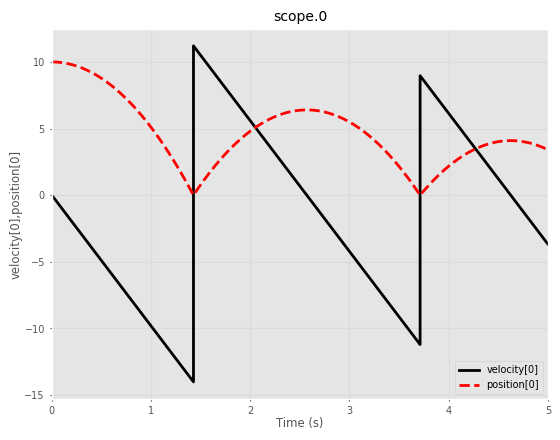


<<< Simulation complete
  block diagram evaluations: 1256
    of which ydot calls:     906  (remaining are post-integration replay + sink passes)
  bd.evaluate() mean time:   18.9 us/call  (total 23.8 ms)
  clocktime speedup:         1.87x  (simulated 5s in 2672.2 ms)
  integration time points:   117
  scheduled event intervals: 102  (each bounded by a clock tick, scheduled event, or terminal marker)
  integrator wall time:       0.048 s  (solve_ivp only; excludes post-integration replay)
  zero-crossing events:      2
    event.0: 2



In [25]:
out = sim.run(bd, T=5)  # , watch=[demand, sum])  # simulate for 5s

# Cart-pole system



This is another classical simulation problem, a non-linear system comprising two coupled dynamical systems.

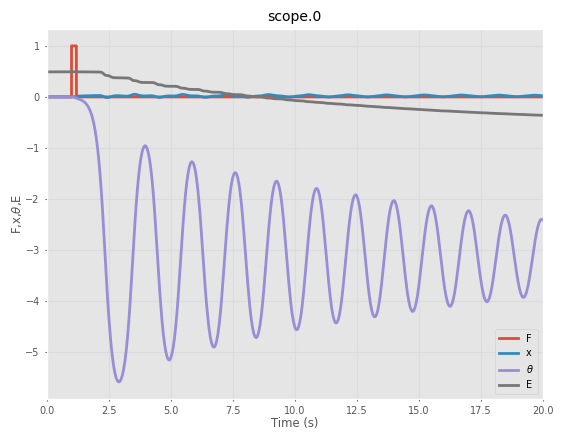

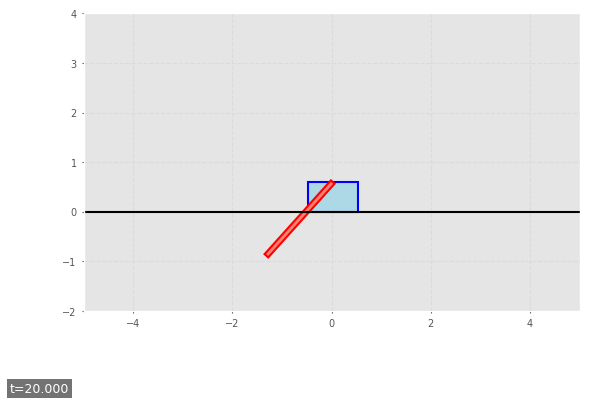

t      = ndarray:float64 (752,)
x      = ndarray:float64 (752, 4)
xnames = ['x_dot:x_0', 'x:x_0', 'theta_dot:x_0', 'theta:x_0'] (list)
y      = ndarray:float64 (752, 3)
ynames = ['_sum.0', 'x', 'theta'] (list)


<Figure size 640x480 with 0 Axes>

In [26]:
%run support/cartpole.py -q 

# Quadrotor flight controller


This block diagram is a complete controller for a quadrotor and drives it to follow a circular path.  The controller has nested loops, from the inside going outwards:

* roll/pitch attitude control
* CoM velocity control
* CoM position control

and a separate yaw controller, independent of the CoM motion

![quadrotor block diagram model](https://raw.githubusercontent.com/petercorke/ICRA2026-modern-software-tools/main/peter/figs/fig4_24.png)

You can open the file `quadrotor.py` to see the model, it's quite large.

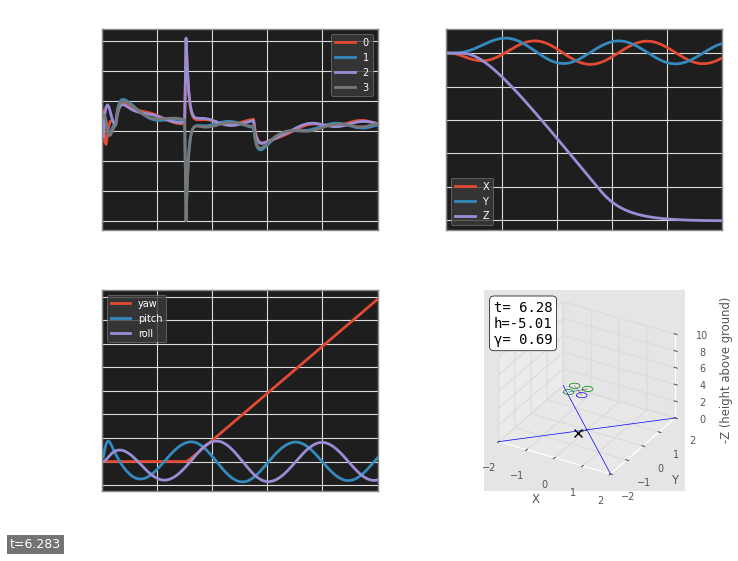

t      = ndarray:float64 (339,)
x      = ndarray:float64 (339, 12)
xnames = ['quadrotor:x_0', 'quadrotor:x_1', 'quadrotor:x_2', 'quadrotor:x_3', 'quadrotor:x_4', 'quadrotor:x_5', 'quadrotor:x_6', 'quadrotor:x_7', 'quadrotor:x_8', 'quadrotor:x_9', 'quadrotor:x_10', 'quadrotor:x_11'] (list)


<Figure size 640x480 with 0 Axes>

In [27]:
%run support/quadrotor.py -q --tiles 2x2

# The block diagram editor



`bdsim` includes a Qt-based editor called `bdedit`.  It provides a decent block diagram drawing environment and the results are saved in JSON files with a `.bd` extension.

![complex](https://raw.githubusercontent.com/petercorke/ICRA2026-modern-software-tools/main/peter/figs/computed-torque.svg)



These diagrams can be parsed into block diagram objects which can then be simulated, as in the examples above.

  INFORMATION: [Block.continuous('forward dynamics', type=fdyn, nin=1, nout=3, nstates=12, inames=['\tau'], onames=['q', 'qd', 'qdd'])] output 2 is not connected
  INFORMATION: [Block.source('Joint space trajectory', type=jtraj, nout=3, onames=['q', 'qd', 'qdd'])] output 2 is not connected


/var/folders/dh/fyyy32c92ksfpsjp1zrq_8780000gn/T/ipykernel_20524/3167442579.py:10: UserWarning: bdload is evaluating model expressions using eval(); load only trusted .bd files. Use allow_eval=False to disable expression evaluation.
  bd = bdload(bd, "support/computed-torque.bd", globalvars=globals())


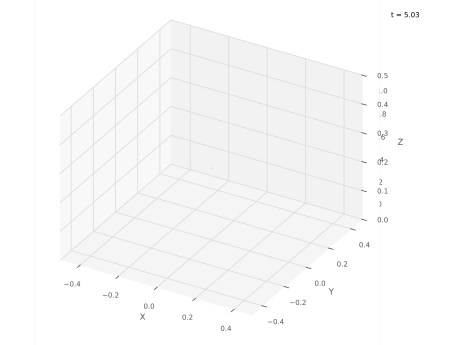

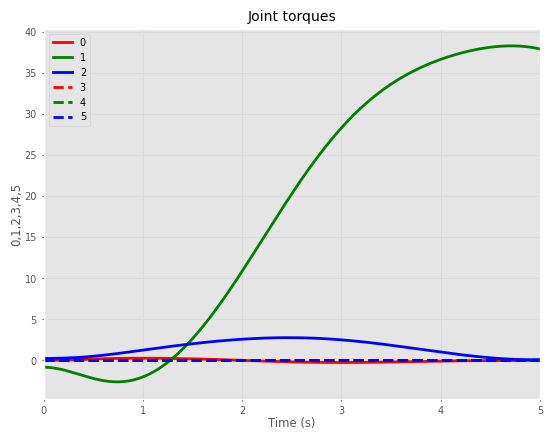

clock1::
         X      = ndarray:float64 (250, 6)
         Xnames = ['Tfb:X_0', 'Tfb:X_1', 'Tfb:X_2', 'Tfb:X_3', 'Tfb:X_4', 'Tfb:X_5'] (list)
         t      = ndarray:float64 (250,)
t      = ndarray:float64 (302,)
x      = ndarray:float64 (302, 12)
xnames = ['forward dynamics:x_0', 'forward dynamics:x_1', 'forward dynamics:x_2', 'forward dynamics:x_3', 'forward dynamics:x_4', 'forward dynamics:x_5', 'forward dynamics:x_6', 'forward dynamics:x_7', 'forward dynamics:x_8', 'forward dynamics:x_9', 'forward dynamics:x_10', 'forward dynamics:x_11'] (list)


In [28]:
from bdsim import BDSim, bdload
from roboticstoolbox.models.DH import Puma560

robot = Puma560().nofriction()

sim = BDSim(animation=True, quiet=True)
bd = sim.blockdiagram()
clock_fb = bd.clock(50, unit="Hz")

bd = bdload(bd, "support/computed-torque.bd", globalvars=globals())
bd.compile()

sim.report(bd, "summary")
out = sim.run(bd, 5)
print(out)
